# Original `allof` + `prepro` cohort inventory

This notebook inventories the closest locally available snapshot of the original MAESTRO pretraining corpus:

- `data/raw/preprocessed-cyto-sources/allof`
- `data/raw/preprocessed-cyto-sources/prepro`

It reads HDF5 headers rather than loading cell matrices, so the full 418-million-cell collection remains memory-safe. It links samples to metadata, inspects the 30-marker panel, summarizes cell counts and cohort composition, and makes the mismatch with the manuscript explicit.

## 1. Setup

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)


def find_project_root() -> Path:
    """Find the repository root from either the root or notebooks directory."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the MAESTRO project root")


project_root = find_project_root()
source_root = project_root / "data/raw/preprocessed-cyto-sources"
cohort_directories = {
    "allof": source_root / "allof",
    "prepro": source_root / "prepro",
}
metadata_path = project_root / "data/metadata/allof/all-metadata.csv"

for cohort_directory in cohort_directories.values():
    if not cohort_directory.exists():
        raise FileNotFoundError(cohort_directory)
if not metadata_path.exists():
    raise FileNotFoundError(metadata_path)

project_root, cohort_directories

(PosixPath('/vast/projects/arjunraj/rohitproject/maestro'),
 {'allof': PosixPath('/vast/projects/arjunraj/rohitproject/maestro/data/raw/preprocessed-cyto-sources/allof'),
  'prepro': PosixPath('/vast/projects/arjunraj/rohitproject/maestro/data/raw/preprocessed-cyto-sources/prepro')})

## 2. Build a memory-safe file inventory

Only dataset shapes, dtypes, keys, and marker names are read. The large `data` and `cell_types` arrays are not materialized.

In [2]:
def decode_strings(values: np.ndarray) -> list[str]:
    """Decode an HDF5 byte-string array."""
    return [
        value.decode("utf-8") if isinstance(value, bytes) else str(value)
        for value in values
    ]


def inventory_hdf5_directory(
    cohort: str,
    directory: Path,
) -> list[dict[str, object]]:
    """Collect file-level HDF5 metadata without loading cell matrices."""
    records = []
    for file_path in sorted(directory.glob("*.h5")):
        with h5py.File(file_path, "r") as h5_file:
            markers = decode_strings(h5_file["feature_names"][:])
            records.append(
                {
                    "sample_name": file_path.stem,
                    "cohort_directory": cohort,
                    "file_path": file_path,
                    "file_size_megabytes": file_path.stat().st_size / 1024**2,
                    "number_cells": h5_file["data"].shape[0],
                    "number_markers": h5_file["data"].shape[1],
                    "data_dtype": str(h5_file["data"].dtype),
                    "cell_type_dtype": str(h5_file["cell_types"].dtype),
                    "hdf5_keys": tuple(sorted(h5_file.keys())),
                    "marker_panel": tuple(markers),
                }
            )
    return records


inventory = pd.DataFrame(
    record
    for cohort, directory in cohort_directories.items()
    for record in inventory_hdf5_directory(cohort, directory)
)
inventory.head()

,sample_name,cohort_directory,file_path,file_size_megabytes,number_cells,number_markers,data_dtype,cell_type_dtype,hdf5_keys,marker_panel
0,Heparin MDIPA_DORA_HD_05Nov24,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,17.575489,130688,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183..."
1,MDIPA_845061_097_Blood Draw_PBMC,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,29.566008,219858,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183..."
2,MDIPA_845061_097_Blood Draw_WBHep,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,16.382488,121816,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183..."
3,MDIPA_845061_098_Blood Draw_PBMC,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,12.858752,95611,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183..."
4,MDIPA_845061_098_Blood Draw_WBHep,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,31.647977,235341,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183..."


In [3]:
inventory_summary = inventory.groupby("cohort_directory", observed=True).agg(
    samples=("sample_name", "size"),
    total_cells=("number_cells", "sum"),
    median_cells=("number_cells", "median"),
    minimum_cells=("number_cells", "min"),
    maximum_cells=("number_cells", "max"),
    disk_gigabytes=("file_size_megabytes", lambda values: values.sum() / 1024),
)
inventory_summary.loc["combined"] = {
    "samples": len(inventory),
    "total_cells": inventory["number_cells"].sum(),
    "median_cells": inventory["number_cells"].median(),
    "minimum_cells": inventory["number_cells"].min(),
    "maximum_cells": inventory["number_cells"].max(),
    "disk_gigabytes": inventory["file_size_megabytes"].sum() / 1024,
}
inventory_summary

,samples,total_cells,median_cells,minimum_cells,maximum_cells,disk_gigabytes
cohort_directory,,,,,,
allof,1692,384529350,208453.0,5523,1389456,50.498553
prepro,178,33715658,182081.5,5319,632684,4.427791
combined,1870,418245008,205555.5,5319,1389456,54.926344


## 3. Inspect schema and marker-panel consistency

In [4]:
schema_counts = inventory[["hdf5_keys", "data_dtype", "cell_type_dtype"]].value_counts()
panel_counts = inventory["marker_panel"].value_counts()

print("HDF5 schema variants:")
display(schema_counts.to_frame("samples"))
print(f"Distinct marker panels: {len(panel_counts)}")

for panel, number_samples in panel_counts.items():
    print(f"\n{number_samples:,} samples with {len(panel)} markers")
    print(list(panel))

assert inventory["number_markers"].eq(30).all()
assert len(panel_counts) == 1
assert inventory["sample_name"].is_unique

HDF5 schema variants:


,,,samples
hdf5_keys,data_dtype,cell_type_dtype,
"(cell_types, data, feature_names)",float32,|S21,1870


Distinct marker panels: 1

1,870 samples with 30 markers
['CD11c', 'CD123', 'CD127', 'CD14', 'CD16', 'CD161', 'CD183', 'CD185', 'CD19', 'CD194', 'CD196', 'CD197', 'CD20', 'CD25', 'CD27', 'CD28', 'CD294', 'CD3', 'CD38', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD56', 'CD57', 'CD66b', 'CD8a', 'HLA-DR', 'IgD', 'TCRgd']


### 3a. Inspect one collected file as a table

Each row below is one cell. `cell_type` is an auxiliary gated annotation; the remaining 30 columns are the arcsinh-transformed marker measurements that MAESTRO consumes.

In [5]:
example_file_path = inventory.loc[
    inventory["cohort_directory"].eq("allof"), "file_path"
].iloc[0]

with h5py.File(example_file_path, "r") as h5_file:
    example_marker_names = decode_strings(h5_file["feature_names"][:])
    example_cells = pd.DataFrame(
        h5_file["data"][:20], columns=example_marker_names
    )
    example_cells.insert(
        0, "cell_type", decode_strings(h5_file["cell_types"][:20])
    )
    example_cells.index.name = "cell_index"
    example_file_summary = pd.Series(
        {
            "file": str(example_file_path),
            "data_shape": h5_file["data"].shape,
            "data_dtype": str(h5_file["data"].dtype),
            "number_markers": len(example_marker_names),
            "hdf5_keys": tuple(sorted(h5_file.keys())),
        },
        name="value",
    )

display(example_file_summary.to_frame())
example_cells

,value
file,/vast/projects/arjunraj/rohitproject/maestro/d...
data_shape,"(130688, 30)"
data_dtype,float32
number_markers,30
hdf5_keys,"(cell_types, data, feature_names)"


,cell_type,CD11c,CD123,CD127,CD14,CD16,CD161,CD183,CD185,CD19,CD194,CD196,CD197,CD20,CD25,CD27,CD28,CD294,CD3,CD38,CD4,CD45,CD45RA,CD45RO,CD56,CD57,CD66b,CD8a,HLA-DR,IgD,TCRgd
cell_index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,Neutrophil,2.03,0.00,0.60,0.92,4.60,0.13,0.00,0.00,0.10,0.23,1.29,0.00,0.00,0.27,0.08,0.00,0.13,0.15,0.83,0.00,1.90,1.01,1.96,0.00,1.88,3.73,0.30,0.12,0.00,1.04
1,T cell CD8 Mem,0.46,0.00,0.18,0.00,0.00,0.00,2.33,0.00,0.29,0.00,1.81,0.00,0.00,0.00,0.00,0.00,0.00,4.35,2.99,0.14,5.10,3.81,0.49,0.00,0.75,0.15,5.59,1.13,0.00,0.12
2,Neutrophil,1.66,0.62,1.37,0.22,4.77,0.00,0.02,0.19,0.44,0.50,2.03,0.14,0.00,0.00,0.00,0.58,0.00,0.62,0.31,0.32,2.11,0.70,2.37,0.00,1.45,2.72,0.74,0.00,0.00,2.12
3,Neutrophil,0.95,0.00,0.70,0.30,3.98,0.00,0.18,0.00,0.00,0.42,2.09,0.00,0.00,0.00,0.00,0.14,0.53,0.58,1.05,0.33,2.40,1.25,2.38,0.12,1.05,3.07,0.05,0.00,0.00,0.26
4,Neutrophil,1.47,0.12,0.52,0.31,4.20,0.65,0.63,0.11,0.37,0.26,1.46,0.00,0.00,0.14,0.29,0.00,0.24,0.14,0.50,0.00,1.95,0.87,1.88,0.00,2.26,3.73,0.89,0.49,0.00,0.00
5,Monocyte Classical,1.91,0.00,0.81,3.34,0.00,0.00,0.35,0.00,0.00,1.45,1.12,0.07,0.00,0.00,0.00,0.12,0.00,0.26,2.86,1.84,3.53,0.49,1.77,0.11,0.00,0.16,0.00,2.44,0.00,0.16
6,T cell CD4 Mem,0.00,0.00,5.05,0.68,0.00,0.00,0.00,0.00,0.00,3.60,3.66,3.78,0.33,1.63,4.20,3.31,0.08,4.52,1.20,4.20,4.72,0.31,2.80,0.19,0.00,0.00,1.13,0.00,0.25,0.00
7,Neutrophil,2.42,0.00,0.21,0.00,4.74,0.11,0.00,0.00,0.04,0.09,2.38,0.05,0.02,0.38,0.16,0.29,0.00,0.79,0.91,0.55,2.68,0.03,2.69,0.64,1.02,3.28,0.04,0.06,0.22,0.72
8,Neutrophil,1.95,0.04,0.12,0.25,4.65,0.05,0.58,0.00,0.16,1.13,1.97,0.49,0.00,0.78,0.68,0.00,0.46,0.78,1.85,0.51,1.98,1.51,2.83,0.00,0.94,3.04,1.37,0.00,0.00,1.06


## 4. Link files to the current metadata table

The metadata table labels both physical directories as dataset `allof`; joining by filename recovers the physical `allof` versus `prepro` split.

In [6]:
metadata = pd.read_csv(metadata_path, dtype={"patient_id": "string"})
allof_metadata = metadata.loc[metadata["dataset"].eq("allof")].copy()

analysis_table = inventory.merge(
    allof_metadata,
    how="left",
    left_on="sample_name",
    right_on="filename",
    validate="one_to_one",
    indicator=True,
)

print(analysis_table["_merge"].value_counts())
assert analysis_table["_merge"].eq("both").all()
analysis_table.head()

_merge
both          1870
left_only        0
right_only       0
Name: count, dtype: int64


,sample_name,cohort_directory,file_path,file_size_megabytes,number_cells,number_markers,data_dtype,cell_type_dtype,hdf5_keys,marker_panel,filename,dataset,platform,diagnosis,treatment,patient_id,sex,age,timepoint,race,ethnicity,treatment_response,pfs_time_months,pfs_event_flag,os_time_months,os_event_flag,QC,irAE_grade,previous_autoimmune_dx,immunosupressant_therapy,_merge
0,Heparin MDIPA_DORA_HD_05Nov24,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,17.575489,130688,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183...",Heparin MDIPA_DORA_HD_05Nov24,allof,CyTOF,BatchControlHD2 Draw 2,NaN,<NA>,Male,33.0,NaN,Asian,Not Hispanic or Latino,NaN,NaN,NaN,NaN,NaN,PASS,NaN,NaN,NaN,both
1,MDIPA_845061_097_Blood Draw_PBMC,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,29.566008,219858,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183...",MDIPA_845061_097_Blood Draw_PBMC,allof,CyTOF,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,both
2,MDIPA_845061_097_Blood Draw_WBHep,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,16.382488,121816,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183...",MDIPA_845061_097_Blood Draw_WBHep,allof,CyTOF,Healthy,NaN,845061.097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TBD,NaN,NaN,NaN,both
3,MDIPA_845061_098_Blood Draw_PBMC,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,12.858752,95611,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183...",MDIPA_845061_098_Blood Draw_PBMC,allof,CyTOF,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,both
4,MDIPA_845061_098_Blood Draw_WBHep,allof,/vast/projects/arjunraj/rohitproject/maestro/d...,31.647977,235341,30,float32,|S21,"(cell_types, data, feature_names)","(CD11c, CD123, CD127, CD14, CD16, CD161, CD183...",MDIPA_845061_098_Blood Draw_WBHep,allof,CyTOF,Healthy,NaN,845061.098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TBD,NaN,NaN,NaN,both


In [7]:
diagnosis_counts = pd.crosstab(
    analysis_table["diagnosis"].fillna("Missing"),
    analysis_table["cohort_directory"],
    margins=True,
).sort_values("All", ascending=False)
diagnosis_counts

cohort_directory,allof,prepro,All
diagnosis,,,
All,1692,178,1870
MS,316,0,316
Lymphoma,219,0,219
Healthy,215,0,215
Premature Infant,0,152,152
ANCA Vasculitis,143,0,143
Long COVID,129,0,129
Melanoma,121,0,121
Acute COVID,110,0,110


In [8]:
metadata_summary = pd.DataFrame(
    {
        "samples": [len(analysis_table)],
        "unique_populated_patient_ids": [
            analysis_table["patient_id"].dropna().nunique()
        ],
        "samples_with_patient_id": [analysis_table["patient_id"].notna().sum()],
        "samples_without_patient_id": [analysis_table["patient_id"].isna().sum()],
        "diagnoses_or_states": [analysis_table["diagnosis"].nunique(dropna=True)],
        "qc_pass": [analysis_table["QC"].eq("PASS").sum()],
        "qc_fail": [analysis_table["QC"].eq("FAIL").sum()],
    }
)
display(metadata_summary)
display(
    pd.crosstab(analysis_table["cohort_directory"], analysis_table["QC"], dropna=False)
)
display(
    pd.crosstab(analysis_table["cohort_directory"], analysis_table["sex"], dropna=False)
)

,samples,unique_populated_patient_ids,samples_with_patient_id,samples_without_patient_id,diagnoses_or_states,qc_pass,qc_fail
0,1870,773,1688,182,23,1592,107


QC,FAIL,FLAG,PASS,TBD,NaN
cohort_directory,,,,,
allof,107,6,1437,109,33
prepro,0,0,155,23,0


sex,Female,Male,NaN
cohort_directory,,,
allof,774,856,62
prepro,64,105,9


## 5. Visualize sample sizes and cohort composition

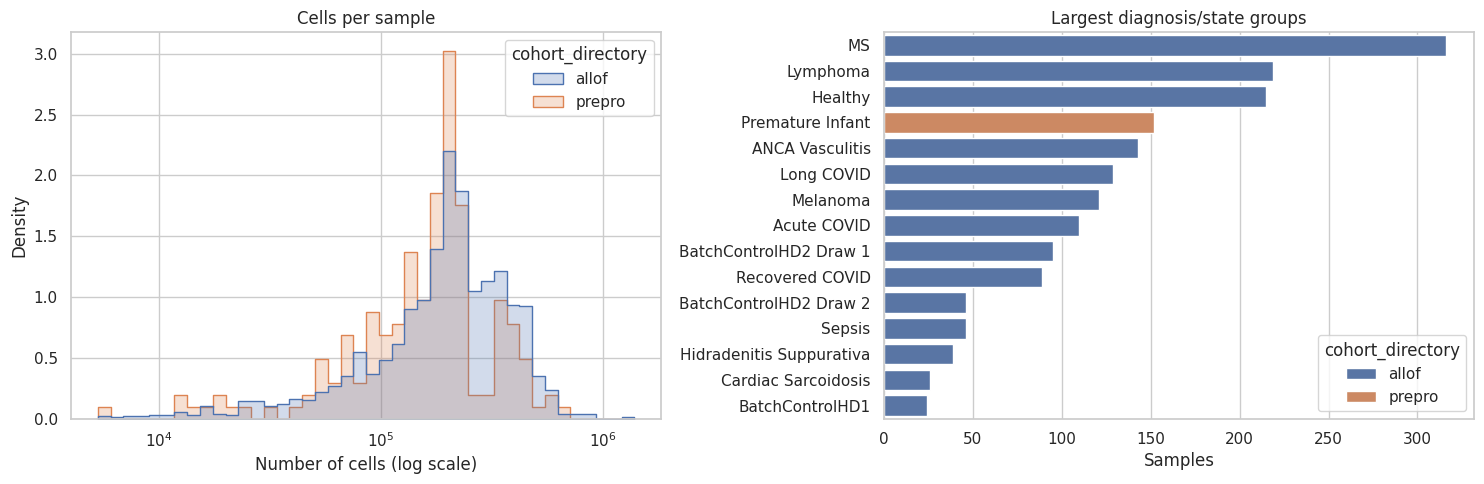

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=analysis_table,
    x="number_cells",
    hue="cohort_directory",
    element="step",
    stat="density",
    common_norm=False,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_title("Cells per sample")
axes[0].set_xlabel("Number of cells (log scale)")

top_diagnoses = analysis_table["diagnosis"].value_counts().head(15).index
diagnosis_plot = analysis_table.loc[analysis_table["diagnosis"].isin(top_diagnoses)]
diagnosis_order = diagnosis_plot["diagnosis"].value_counts().index
sns.countplot(
    data=diagnosis_plot,
    y="diagnosis",
    hue="cohort_directory",
    order=diagnosis_order,
    ax=axes[1],
)
axes[1].set_title("Largest diagnosis/state groups")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [10]:
largest_samples = analysis_table.nlargest(15, "number_cells")[
    ["sample_name", "cohort_directory", "diagnosis", "QC", "number_cells"]
]
smallest_samples = analysis_table.nsmallest(15, "number_cells")[
    ["sample_name", "cohort_directory", "diagnosis", "QC", "number_cells"]
]

print("Largest samples")
display(largest_samples)
print("Smallest samples")
display(smallest_samples)

Largest samples


,sample_name,cohort_directory,diagnosis,QC,number_cells
935,MDIPA_MESSI_994724_D0,allof,NaN,NaN,1389456
877,MDIPA_MESSI_221270_FreshDay0,allof,Sepsis,PASS,921858
706,MDIPA_LRAD00106_V4,allof,Lymphoma,PASS,849043
1009,MDIPA_MESSI_994915_D7,allof,Acute COVID,PASS,841071
986,MDIPA_MESSI_994869_18-24Months,allof,Recovered COVID,PASS,819637
876,MDIPA_MESSI_221204_FreshDay7,allof,Sepsis,PASS,806717
705,MDIPA_LRAD00106_V3,allof,Lymphoma,PASS,802937
707,MDIPA_LRAD00106_V5,allof,Lymphoma,PASS,774165
871,MDIPA_MESSI_221173_FreshDay0,allof,Sepsis,PASS,741658
872,MDIPA_MESSI_221179_FreshDay0,allof,Sepsis,PASS,707840


Smallest samples


,sample_name,cohort_directory,diagnosis,QC,number_cells
1766,MDIPA_PREPRO_020_V5,prepro,Premature Infant,PASS,5319
934,MDIPA_MESSI_994723_D0,allof,NaN,NaN,5523
1544,MDIPA_PD1_17-2819_PD1_D1,allof,Melanoma,PASS,5896
1541,MDIPA_PD1_16-2150_PD1_D1,allof,Melanoma,PASS,6482
421,MDIPA_IHCV2020_030_T3,allof,Healthy,PASS,7294
566,MDIPA_ISPY_768450_Day7,allof,Acute COVID,FAIL,7442
1627,MDIPA_PD1_21-4269_BoostD0,allof,Melanoma,PASS,8248
1057,MDIPA_MESSI_HD2020_020F,allof,Healthy,PASS,8602
1391,MDIPA_MS_079_V9,allof,MS,FAIL,9383
1145,MDIPA_MS_012_V10,allof,MS,FAIL,9396


## 6. Reconcile this snapshot with the manuscript

The paper reports 1,792 samples, more than 418 million cells, and a median of 215,442 cells. This local snapshot is close in biological content but is not the exact frozen training manifest.

In [11]:
manuscript_comparison = pd.DataFrame(
    {
        "metric": ["Samples", "Total cells", "Median cells per sample"],
        "manuscript": [1_792, ">418,000,000", 215_442],
        "available_snapshot": [
            len(analysis_table),
            int(analysis_table["number_cells"].sum()),
            float(analysis_table["number_cells"].median()),
        ],
    }
)
manuscript_comparison

,metric,manuscript,available_snapshot
0,Samples,1792,1870.0
1,Total cells,">418,000,000",418245008.0
2,Median cells per sample,215442,205555.5


### Interpretation

- This snapshot has the correct whole-blood biology, original 30-marker panel, and approximately the manuscript-scale cell count.
- It contains 1,870 files rather than the reported 1,792, and its median sample size differs.
- Do not infer the manuscript training manifest by applying current `QC == PASS`: the Methods state that low-quality samples were removed only after pretraining.
- Before claiming an exact reproduction, obtain the original 1,792-sample manifest or checkpoint configuration.
- For an approximate retraining, preserve patient-grouped splits and document precisely which local files were included.

## Optional manifest export

Uncomment this only when you are ready to freeze an explicit retraining cohort.

In [12]:
# manifest_columns = [
#     "sample_name",
#     "cohort_directory",
#     "file_path",
#     "number_cells",
#     "diagnosis",
#     "patient_id",
#     "QC",
# ]
# output_path = (
#     project_root
#     / "data/metadata/allof/available-legacy-training-manifest.csv"
# )
# analysis_table[manifest_columns].to_csv(output_path, index=False)
# output_path